# Image Processing Notebook: Plot the H Cross-Section (from Transmission)


This notebook takes the processed transmission imagesand plot the H Cross-sections from specific ROIs

## Initial Settings

### Import Libraries

In [1]:
import sys
sys.path.append(r'..\01_Functions')
from step_functions import *
from dict_functions import *
from proc_functions import *
from img_functions import *
from plotting_cs import *
from cross_sections import *
import seaborn as sns
%matplotlib inline
pd.set_option('display.max_rows', 20)

### Provide the Spectra.txt file from any of the experiments. 
These are the neutron arrival times the MCP detected

In [2]:
# %load select_file('spectra_file')
spectra_file = r"J:\700 Campaigns - internal\2022\PSI22_04NI\Raw_images\exp2000\exp2200_LP40_deg\02_pos00\IMAT00018918_02_pos00_001_Spectra.txt"

### Provide the directory for saving results

In [3]:
# %load select_directory('dst_dir')
dst_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI\00_Processed\02_Cross_sections_results\01_operando"

### Provide the directory reference measurements (this is a special case)

In [4]:
# %load select_directory('ref_dir')
ref_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI\00_Processed\01_Transmission_results\000_exp2000\00_empty_ref02"

### Set the ROIs to analyze

In [5]:
ref_dict = read_saved_dict (ref_dir, proc_folder = [])

Reading Images: 100%|████████████████████████████| 5/5 [00:00<00:00,  7.82it/s]


#### Extract an averaged image for each key
For each `proc_folder` (acquisition), an averaged image will be extracted

In [6]:
avg_imgs = []
for key, value in ref_dict.items():
    img =  avg_frames_dict (value, output_type = 'img', start_img = 15, end_slice = 20)
    avg_imgs.append(img[0])

#### Select the ROIs
For simplicity handling the names, `ROIs_` before the name of the `proc_folder` is required

In [7]:
# %load select_multiple_rois(proc_folder[0], avg_images[0], cmap = 'flag')

# from each chip region LP30 degraded
ROIs_02_pos00 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]
ROIs_04_pos01 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 38], [145, 152, 78, 40]] #
ROIs_06_pos02 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]
ROIs_08_pos03 = [[146, 35, 78, 69], [33, 35, 78, 69], [33, 154, 78, 69], [145, 152, 78, 69]]
ROIs_10_pos04 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]

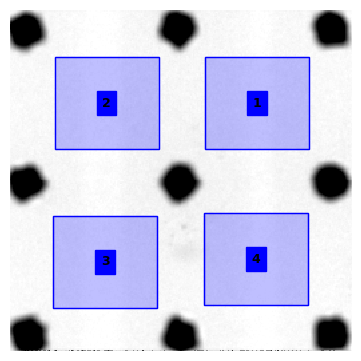

In [8]:
show_img(avg_imgs[4], dr = [(ROIs_10_pos04, 'blue')], cmap='gray', nrows=3, ncols=2, index=5)

#### Create a dictionary of the ROIs

In [9]:
ref_rois_dict = {}
for name in ref_dict.keys():
    rois_name = 'ROIs_'+ name
    for rois in [rois_name]:
        ref_rois_dict[rois] = eval(rois)

In [10]:
rois_dict = {}
rois_name = 'ROIs_02_pos00'
for n in range(10):
    rois_dict[rois_name] = eval(rois_name)        

## Ramp down 10C

### To transmission images

In [11]:
src_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI\00_Processed\01_Transmission_results\000_exp3000\03_LP30_ramp_down_10C"

### Read the directory and setup the ROIs
You can specify a single folder but if you want all the folders in the `src_dir`, leave `proc_folder=[]`.

In [12]:
src_dict = read_saved_dict (src_dir, proc_folder = [])
ref_dict = read_saved_dict (ref_dir, proc_folder = [])

Reading Images: 100%|████████████████████████████| 5/5 [00:00<00:00,  6.12it/s]


### Extract the values

In [13]:
img_vals = get_roi_values (src_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 20, 
                                 flight_path = 56, start_slice = 0, name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

ref_vals = get_roi_values (ref_dict, ref_rois_dict, spectra_file, save_path = dst_dir, binning = 20, 
                                 flight_path = 56, start_slice = 0, name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

In [14]:
data_wvl = img_vals['Wavelength [Å]']

new_ref_vals = pd.DataFrame()

for name in src_dict.keys():
    for idx in range(1,5,1):
        col_name = 'Values_'+ name + '_roi_' + str(idx)
        new_ref_vals [col_name] = ref_vals ['Values_10_pos04_roi_' + str(idx)]
        
new_ref_vals = pd.concat([data_wvl,new_ref_vals], axis = 1)

In [15]:
data_wvl = img_vals['Wavelength [Å]']

new_ref_vals = new_ref_vals.loc[2:36]
new_ref_vals = new_ref_vals.reset_index(drop=True)

img_vals = img_vals.loc[2:36]
img_vals = img_vals.reset_index(drop=True)

In [16]:
trans_rois = prepare_trans_data(img_vals, data_ref = new_ref_vals, data_output = 'transmission')

In [17]:
trans_rois

,Wavelength [Å],Transmission_02_pos00_roi_1,Transmission_02_pos00_roi_2,Transmission_02_pos00_roi_3,Transmission_02_pos00_roi_4
0,1.279359,0.875326,0.875765,0.878019,0.880451
1,1.531952,0.870418,0.870956,0.871698,0.870268
2,1.776463,0.859851,0.859779,0.860244,0.861730
3,2.032233,0.851841,0.851902,0.853281,0.854063
4,2.304880,0.847278,0.847224,0.849038,0.849311
...,...,...,...,...,...
30,8.806118,0.740938,0.751128,0.741808,0.744589
31,9.039954,0.749494,0.748375,0.756101,0.748363
32,9.271439,0.744992,0.743931,0.748211,0.743086
33,9.525303,0.730217,0.734892,0.737938,0.725693


### Get the transmission table
If the images given before are transmission, leave empty the data_ref in the `prepare_trans_data` function. 
If not, run the previous line but with the reference images directory.

Depending on the **data_output** chosen ('transmission'. 'optical density', 'total cs', or 'h cs'). if the requested data is `total cs` or `h cs`, a dictionary of compounds is required. This is basically a list of the material expected **in oder** from the ROIs given before.

The  full dictionary of cross-sections is located at the top of the `plotting_cs` function. In the notebook, we are using only those that are required to avoid clogging the information.

#### H cross section parameters

In [18]:
thickness = 0.060

ec = {'abbv': 'EC', 'composition' : {'C':3.0, 'H':4.0, 'O':3.0},'density':1.32, 'thickness': thickness}
dmc = {'abbv': 'DMC','composition' : {'C':3.0, 'H':6.0, 'O':3.0}, 'density':1.07, 'thickness': thickness}
dec = {'abbv': 'DEC','composition' : {'C':5.0, 'H':10.0, 'O':3.0}, 'density':0.975, 'thickness': thickness}
lipf6 = {'abbv': 'LiPF6','composition' : {'LI':1.0, 'P':1.0, 'F':6.0}, 'density':1.5, 'thickness': thickness}
ec_dmc_11v = {'abbv': 'EC_DMC (1:1v)','molecules' : [ec,0.5,dmc,0.5], 'density':1.1955, 'thickness': thickness}
ec_dec_11v = {'abbv': 'EC_DEC (1:1v)','molecules' : [ec,0.5,dec,0.5], 'density':1.148, 'thickness': thickness}
#lp30 = {'abbv': 'LP30','molecules' : [ec, 0.501683056,dmc, 0.406359477, lipf6, 0.091957467], 'density':1.2795, 'thickness': thickness}
#lp40 = {'abbv': 'LP40','molecules' : [ec, 0.447925137,dec, 0.447925137, lipf6, 0.104149725], 'density':1.2635, 'thickness': thickness}

lp30 = {'abbv': 'LP30','molecules' : [ec, 0.446003162,dmc, 0.446003162, lipf6, 0.107993676], 'density':1.2284, 'thickness': thickness}
lp40 = {'abbv': 'LP40','molecules' : [ec, 0.447925137,dec, 0.447925137, lipf6, 0.104149725], 'density':1.1847, 'thickness': thickness}

In [19]:
compounds_dict = [lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30,
                 lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30]

#### Get the cross sections
Function to get the cross sections, the requested_cs is a list of the desired cross-sections options are ['total_cs','h_cs','li_cs']

**it was determined that an interpolation via Savgol of 5,2 does not affect the outcome but improves the data visualization. Therefore, it was kept**

In [20]:
res_data = prepare_trans_data(trans_rois, data_output = 'h cs', compounds_dict = compounds_dict)
res_data = dataframe_to_savgol(res_data, 5, 2)

Data_imgs variable taken as transmission images


In [21]:
save_DF (dst_dir, res_data, df_name = '01_ramp_down_H_CS.xlsx', sheet_name = 'ramp_down_10C', mode = 'w')

In [32]:
    # position column name extraction
pos00 = [column for column in res_data if 'pos00' in column]

    # recalling the data with the specified columns and the wavelength column up front
cs_pos00_dat = pd.concat([data_wvl, res_data[pos00]], axis = 1)

avg_vals_dat10 = pd.DataFrame(data_wvl)
avg_vals_dat10 ['pos00'] = cs_pos00_dat.iloc[:,1:].mean(axis=1)

In [33]:
cs_pos00_dat=cs_pos00_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')

avg_vals_dat10=avg_vals_dat10.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')

<AxesSubplot:xlabel='Wavelength [Å]', ylabel='cross-section [barns]'>

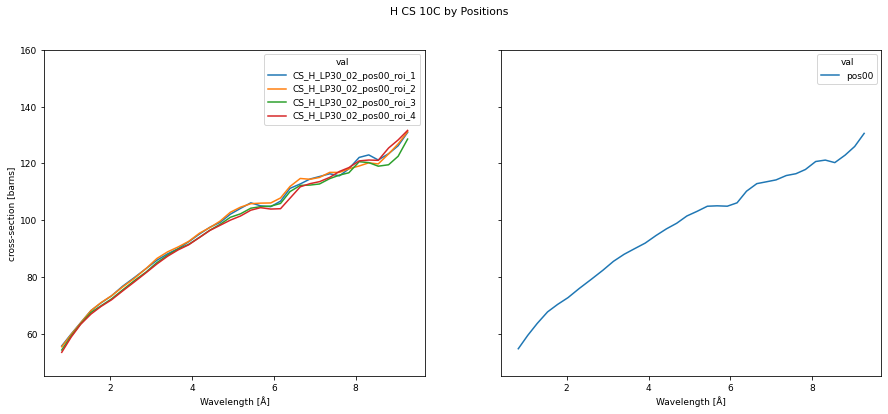

In [34]:
fig0, ax = plt.subplots(1,2, figsize = (15,6), sharey = True)
fig0.suptitle('H CS 10C by Positions')
plt.ylim([45,160])
sns.lineplot(ax = ax[0], data = cs_pos00_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[1], data = avg_vals_dat10, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')

## Ramp down 0C

### To transmission images

In [35]:
src_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI\00_Processed\01_Transmission_results\000_exp3000\04_LP30_ramp_down_0C"

### Read the directory and setup the ROIs
You can specify a single folder but if you want all the folders in the `src_dir`, leave `proc_folder=[]`.

In [36]:
src_dict = read_saved_dict (src_dir, proc_folder = [])
ref_dict = read_saved_dict (ref_dir, proc_folder = [])

Reading Images: 100%|████████████████████████████| 5/5 [00:00<00:00,  7.29it/s]


### Extract the values

In [37]:
img_vals = get_roi_values (src_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 20, 
                                 flight_path = 56, start_slice = 0, name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

ref_vals = get_roi_values (ref_dict, ref_rois_dict, spectra_file, save_path = dst_dir, binning = 20, 
                                 flight_path = 56, start_slice = 0, name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

In [38]:
data_wvl = img_vals['Wavelength [Å]']

new_ref_vals = pd.DataFrame()

for name in src_dict.keys():
    for idx in range(1,5,1):
        col_name = 'Values_'+ name + '_roi_' + str(idx)
        new_ref_vals [col_name] = ref_vals ['Values_10_pos04_roi_' + str(idx)]
        
new_ref_vals = pd.concat([data_wvl,new_ref_vals], axis = 1)

In [39]:
data_wvl = img_vals['Wavelength [Å]']

new_ref_vals = new_ref_vals.loc[2:36]
new_ref_vals = new_ref_vals.reset_index(drop=True)

img_vals = img_vals.loc[2:36]
img_vals = img_vals.reset_index(drop=True)

In [40]:
trans_rois = prepare_trans_data(img_vals, data_ref = new_ref_vals, data_output = 'transmission')

In [41]:
trans_rois

,Wavelength [Å],Transmission_02_pos00_roi_1,Transmission_02_pos00_roi_2,Transmission_02_pos00_roi_3,Transmission_02_pos00_roi_4
0,1.279359,0.877572,0.878779,0.882779,0.885975
1,1.531952,0.869205,0.871717,0.874909,0.871850
2,1.776463,0.859461,0.859684,0.863545,0.865029
3,2.032233,0.855599,0.856102,0.860133,0.861156
4,2.304880,0.849356,0.851190,0.855835,0.855729
...,...,...,...,...,...
30,8.806118,0.750042,0.747969,0.755685,0.751155
31,9.039954,0.753708,0.756935,0.765142,0.764811
32,9.271439,0.749610,0.752628,0.752897,0.751067
33,9.525303,0.744417,0.743587,0.760516,0.755701


### Get the transmission table
If the images given before are transmission, leave empty the data_ref in the `prepare_trans_data` function. 
If not, run the previous line but with the reference images directory.

Depending on the **data_output** chosen ('transmission'. 'optical density', 'total cs', or 'h cs'). if the requested data is `total cs` or `h cs`, a dictionary of compounds is required. This is basically a list of the material expected **in oder** from the ROIs given before.

The  full dictionary of cross-sections is located at the top of the `plotting_cs` function. In the notebook, we are using only those that are required to avoid clogging the information.

#### Get the cross sections
Function to get the cross sections, the requested_cs is a list of the desired cross-sections options are ['total_cs','h_cs','li_cs']

**it was determined that an interpolation via Savgol of 5,2 does not affect the outcome but improves the data visualization. Therefore, it was kept**

In [42]:
res_data = prepare_trans_data(trans_rois, data_output = 'h cs', compounds_dict = compounds_dict)
res_data = dataframe_to_savgol(res_data, 5, 2)

Data_imgs variable taken as transmission images


In [43]:
save_DF (dst_dir, res_data, df_name = '01_ramp_down_H_CS.xlsx', sheet_name = 'ramp_down_00C', mode = 'a')

In [44]:
    # position column name extraction
pos00 = [column for column in res_data if 'pos00' in column]

    # recalling the data with the specified columns and the wavelength column up front
cs_pos00_dat = pd.concat([data_wvl, res_data[pos00]], axis = 1)

avg_vals_dat00 = pd.DataFrame(data_wvl)
avg_vals_dat00 ['pos00'] = cs_pos00_dat.iloc[:,1:].mean(axis=1)

In [45]:
cs_pos00_dat=cs_pos00_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')

avg_vals_dat00=avg_vals_dat00.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')

<AxesSubplot:xlabel='Wavelength [Å]', ylabel='cross-section [barns]'>

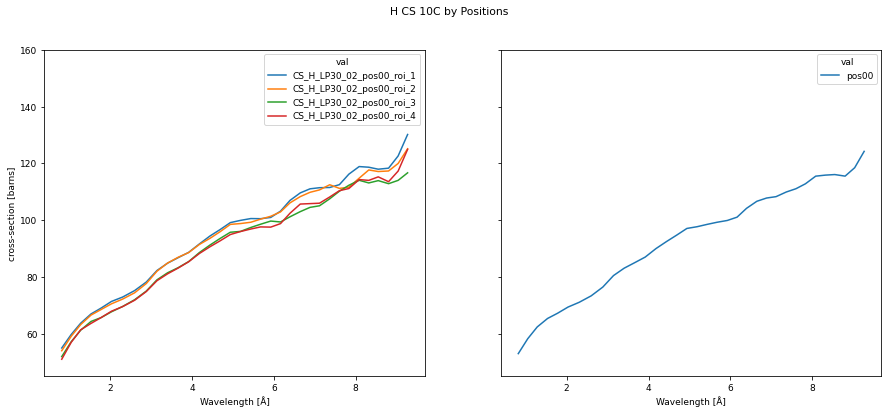

In [46]:
fig0, ax = plt.subplots(1,2, figsize = (15,6), sharey = True)
fig0.suptitle('H CS ramp down 0C')
plt.ylim([45,160])
sns.lineplot(ax = ax[0], data = cs_pos00_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[1], data = avg_vals_dat00, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')

## Ramp down -10C

### To transmission images

In [47]:
src_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI\00_Processed\01_Transmission_results\000_exp3000\05_LP30_ramp_down_m10C"

### Read the directory and setup the ROIs
You can specify a single folder but if you want all the folders in the `src_dir`, leave `proc_folder=[]`.

In [48]:
src_dict = read_saved_dict (src_dir, proc_folder = [])
ref_dict = read_saved_dict (ref_dir, proc_folder = [])

Reading Images: 100%|████████████████████████████| 5/5 [00:00<00:00,  7.90it/s]


### Extract the values

In [49]:
img_vals = get_roi_values (src_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 20, 
                                 flight_path = 56, start_slice = 0, name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

ref_vals = get_roi_values (ref_dict, ref_rois_dict, spectra_file, save_path = dst_dir, binning = 20, 
                                 flight_path = 56, start_slice = 0, name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

In [50]:
data_wvl = img_vals['Wavelength [Å]']

new_ref_vals = pd.DataFrame()

for name in src_dict.keys():
    for idx in range(1,5,1):
        col_name = 'Values_'+ name + '_roi_' + str(idx)
        new_ref_vals [col_name] = ref_vals ['Values_10_pos04_roi_' + str(idx)]
        
new_ref_vals = pd.concat([data_wvl,new_ref_vals], axis = 1)

In [51]:
data_wvl = img_vals['Wavelength [Å]']

new_ref_vals = new_ref_vals.loc[2:36]
new_ref_vals = new_ref_vals.reset_index(drop=True)

img_vals = img_vals.loc[2:36]
img_vals = img_vals.reset_index(drop=True)

In [52]:
trans_rois = prepare_trans_data(img_vals, data_ref = new_ref_vals, data_output = 'transmission')

In [53]:
trans_rois

,Wavelength [Å],Transmission_02_pos00_roi_1,Transmission_02_pos00_roi_2,Transmission_02_pos00_roi_3,Transmission_02_pos00_roi_4
0,1.279359,0.871823,0.873897,0.881956,0.881271
1,1.531952,0.866530,0.868142,0.872151,0.871438
2,1.776463,0.858414,0.860322,0.863391,0.863178
3,2.032233,0.853066,0.854600,0.857259,0.857463
4,2.304880,0.847395,0.849268,0.852050,0.852190
...,...,...,...,...,...
30,8.806118,0.751449,0.764393,0.763451,0.765360
31,9.039954,0.753062,0.763225,0.764654,0.760190
32,9.271439,0.755070,0.761323,0.765086,0.756298
33,9.525303,0.746247,0.751703,0.747969,0.748928


### Get the transmission table
If the images given before are transmission, leave empty the data_ref in the `prepare_trans_data` function. 
If not, run the previous line but with the reference images directory.

Depending on the **data_output** chosen ('transmission'. 'optical density', 'total cs', or 'h cs'). if the requested data is `total cs` or `h cs`, a dictionary of compounds is required. This is basically a list of the material expected **in oder** from the ROIs given before.

The  full dictionary of cross-sections is located at the top of the `plotting_cs` function. In the notebook, we are using only those that are required to avoid clogging the information.

#### Get the cross sections
Function to get the cross sections, the requested_cs is a list of the desired cross-sections options are ['total_cs','h_cs','li_cs']

**it was determined that an interpolation via Savgol of 5,2 does not affect the outcome but improves the data visualization. Therefore, it was kept**

In [54]:
res_data = prepare_trans_data(trans_rois, data_output = 'h cs', compounds_dict = compounds_dict)
res_data = dataframe_to_savgol(res_data, 5, 2)

Data_imgs variable taken as transmission images


In [56]:
save_DF (dst_dir, res_data, df_name = '01_ramp_down_H_CS.xlsx', sheet_name = 'ramp_down_m10C', mode = 'a')

In [57]:
    # position column name extraction
pos00 = [column for column in res_data if 'pos00' in column]

    # recalling the data with the specified columns and the wavelength column up front
cs_pos00_dat = pd.concat([data_wvl, res_data[pos00]], axis = 1)

avg_vals_datm10 = pd.DataFrame(data_wvl)
avg_vals_datm10 ['pos00'] = cs_pos00_dat.iloc[:,1:].mean(axis=1)

In [58]:
cs_pos00_dat=cs_pos00_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')

avg_vals_datm10=avg_vals_datm10.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')

<AxesSubplot:xlabel='Wavelength [Å]', ylabel='cross-section [barns]'>

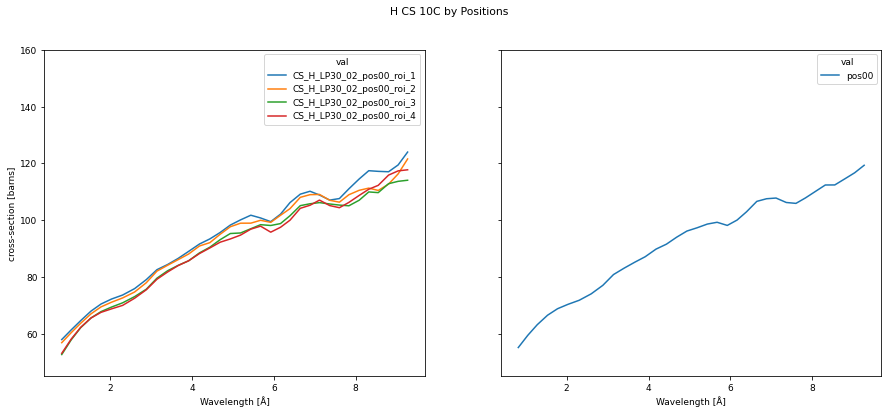

In [59]:
fig0, ax = plt.subplots(1,2, figsize = (15,6), sharey = True)
fig0.suptitle('H CS ramp down m10C')
plt.ylim([45,160])
sns.lineplot(ax = ax[0], data = cs_pos00_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[1], data = avg_vals_datm10, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')

## Ramp down -20C

### To transmission images

In [60]:
src_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI\00_Processed\01_Transmission_results\000_exp3000\06_LP30_ramp_down_m20C"

### Read the directory and setup the ROIs
You can specify a single folder but if you want all the folders in the `src_dir`, leave `proc_folder=[]`.

In [61]:
src_dict = read_saved_dict (src_dir, proc_folder = [])
ref_dict = read_saved_dict (ref_dir, proc_folder = [])

Reading Images: 100%|████████████████████████████| 5/5 [00:00<00:00,  8.63it/s]


### Extract the values

In [62]:
img_vals = get_roi_values (src_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 20, 
                                 flight_path = 56, start_slice = 0, name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

ref_vals = get_roi_values (ref_dict, ref_rois_dict, spectra_file, save_path = dst_dir, binning = 20, 
                                 flight_path = 56, start_slice = 0, name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

In [63]:
data_wvl = img_vals['Wavelength [Å]']

new_ref_vals = pd.DataFrame()

for name in src_dict.keys():
    for idx in range(1,5,1):
        col_name = 'Values_'+ name + '_roi_' + str(idx)
        new_ref_vals [col_name] = ref_vals ['Values_10_pos04_roi_' + str(idx)]
        
new_ref_vals = pd.concat([data_wvl,new_ref_vals], axis = 1)

In [64]:
data_wvl = img_vals['Wavelength [Å]']

new_ref_vals = new_ref_vals.loc[2:36]
new_ref_vals = new_ref_vals.reset_index(drop=True)

img_vals = img_vals.loc[2:36]
img_vals = img_vals.reset_index(drop=True)

In [65]:
trans_rois = prepare_trans_data(img_vals, data_ref = new_ref_vals, data_output = 'transmission')

In [66]:
trans_rois

,Wavelength [Å],Transmission_02_pos00_roi_1,Transmission_02_pos00_roi_2,Transmission_02_pos00_roi_3,Transmission_02_pos00_roi_4
0,1.279359,0.874402,0.876206,0.882877,0.879083
1,1.531952,0.868321,0.869109,0.873509,0.870461
2,1.776463,0.860284,0.860727,0.863433,0.862350
3,2.032233,0.853284,0.855909,0.859478,0.858525
4,2.304880,0.847826,0.850102,0.853912,0.851074
...,...,...,...,...,...
30,8.806118,0.766967,0.769959,0.773306,0.767012
31,9.039954,0.762642,0.768553,0.774145,0.767213
32,9.271439,0.765678,0.774338,0.778037,0.780159
33,9.525303,0.759861,0.767597,0.778480,0.754894


### Get the transmission table
If the images given before are transmission, leave empty the data_ref in the `prepare_trans_data` function. 
If not, run the previous line but with the reference images directory.

Depending on the **data_output** chosen ('transmission'. 'optical density', 'total cs', or 'h cs'). if the requested data is `total cs` or `h cs`, a dictionary of compounds is required. This is basically a list of the material expected **in oder** from the ROIs given before.

The  full dictionary of cross-sections is located at the top of the `plotting_cs` function. In the notebook, we are using only those that are required to avoid clogging the information.

#### Get the cross sections
Function to get the cross sections, the requested_cs is a list of the desired cross-sections options are ['total_cs','h_cs','li_cs']

**it was determined that an interpolation via Savgol of 5,2 does not affect the outcome but improves the data visualization. Therefore, it was kept**

In [67]:
res_data = prepare_trans_data(trans_rois, data_output = 'h cs', compounds_dict = compounds_dict)
res_data = dataframe_to_savgol(res_data, 5, 2)

Data_imgs variable taken as transmission images


In [68]:
save_DF (dst_dir, res_data, df_name = '01_ramp_down_H_CS.xlsx', sheet_name = 'ramp_down_m20C', mode = 'a')

In [72]:
    # position column name extraction
pos00 = [column for column in res_data if 'pos00' in column]

    # recalling the data with the specified columns and the wavelength column up front
cs_pos00_dat = pd.concat([data_wvl, res_data[pos00]], axis = 1)

avg_vals_datm20 = pd.DataFrame(data_wvl)
avg_vals_datm20 ['pos00'] = cs_pos00_dat.iloc[:,1:].mean(axis=1)

In [73]:
cs_pos00_dat=cs_pos00_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')

avg_vals_datm20=avg_vals_datm20.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')

<AxesSubplot:xlabel='Wavelength [Å]', ylabel='cross-section [barns]'>

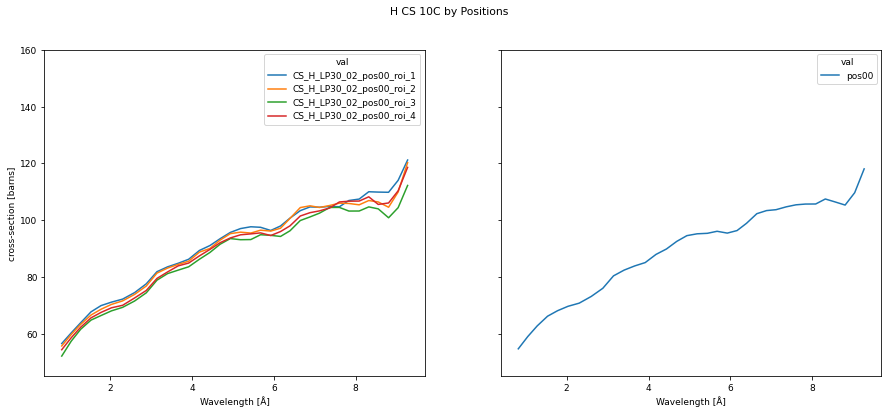

In [74]:
fig0, ax = plt.subplots(1,2, figsize = (15,6), sharey = True)
fig0.suptitle('H CS ramp down m20C')
plt.ylim([45,160])
sns.lineplot(ax = ax[0], data = cs_pos00_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[1], data = avg_vals_datm20, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')

## Ramp down 20C reprocessed

### To transmission images

In [169]:
src_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI\00_Processed\01_Transmission_results\000_exp3000\02_LP30_after_oper_20C"

### Read the directory and setup the ROIs
You can specify a single folder but if you want all the folders in the `src_dir`, leave `proc_folder=[]`.

In [170]:
src_dict = read_saved_dict (src_dir, proc_folder = [])
ref_dict = read_saved_dict (ref_dir, proc_folder = [])

Reading Images: 100%|████████████████████████████| 5/5 [00:01<00:00,  4.41it/s]


In [171]:
rois_dict = {}
for name in ref_dict.keys():
    rois_name = 'ROIs_'+ name
    for rois in [rois_name]:
        rois_dict[rois] = eval(rois)

### Extract the values

In [172]:
img_vals = get_roi_values (src_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 20, 
                                 flight_path = 56, start_slice = 0, name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

ref_vals = get_roi_values (ref_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 20, 
                                 flight_path = 56, start_slice = 0, name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

In [173]:
ref_vals = ref_vals.loc[2:36]
ref_vals = ref_vals.reset_index(drop=True)

img_vals = img_vals.loc[2:36]
img_vals = img_vals.reset_index(drop=True)

data_wvl = img_vals['Wavelength [Å]']

In [174]:
trans_rois = prepare_trans_data(img_vals, data_ref = ref_vals, data_output = 'transmission')

In [175]:
trans_rois

,Wavelength [Å],Transmission_02_pos00_roi_1,Transmission_02_pos00_roi_2,Transmission_02_pos00_roi_3,Transmission_02_pos00_roi_4,Transmission_04_pos01_roi_1,Transmission_04_pos01_roi_2,Transmission_04_pos01_roi_3,Transmission_04_pos01_roi_4,Transmission_06_pos02_roi_1,...,Transmission_06_pos02_roi_3,Transmission_06_pos02_roi_4,Transmission_08_pos03_roi_1,Transmission_08_pos03_roi_2,Transmission_08_pos03_roi_3,Transmission_08_pos03_roi_4,Transmission_10_pos04_roi_1,Transmission_10_pos04_roi_2,Transmission_10_pos04_roi_3,Transmission_10_pos04_roi_4
0,1.279359,0.881226,0.878616,0.883791,0.877185,0.881732,0.882023,0.885755,0.880370,0.873884,...,0.880848,0.878336,0.884521,0.883158,0.884992,0.890240,0.876984,0.878185,0.885953,0.887707
1,1.531952,0.870360,0.871474,0.874139,0.868704,0.870413,0.872137,0.872449,0.868728,0.868727,...,0.872051,0.875560,0.876672,0.870787,0.874741,0.872025,0.872203,0.870723,0.875751,0.873278
2,1.776463,0.859738,0.859855,0.863205,0.858995,0.861998,0.860102,0.860630,0.860775,0.858127,...,0.864773,0.865507,0.864403,0.861472,0.866469,0.863950,0.866150,0.864193,0.867242,0.867016
3,2.032233,0.854241,0.854747,0.856147,0.853211,0.855035,0.856603,0.857509,0.854860,0.851588,...,0.856584,0.858986,0.859646,0.856651,0.861244,0.860055,0.859498,0.858669,0.863341,0.861737
4,2.304880,0.849265,0.849381,0.852957,0.848155,0.850928,0.850355,0.852526,0.849254,0.847262,...,0.852874,0.855181,0.852681,0.849585,0.854255,0.852694,0.853161,0.852115,0.855535,0.854406
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30,8.806118,0.729235,0.726857,0.725222,0.723732,0.745906,0.745078,0.728432,0.731308,0.736396,...,0.738562,0.736957,0.740587,0.727258,0.741140,0.742179,0.730300,0.733071,0.731765,0.734491
31,9.039954,0.740124,0.733147,0.729239,0.733530,0.732338,0.736243,0.731010,0.726881,0.726559,...,0.741920,0.735578,0.740045,0.723729,0.728458,0.732690,0.734237,0.740582,0.741140,0.733666
32,9.271439,0.734890,0.724592,0.731829,0.736610,0.733150,0.740080,0.724759,0.714466,0.733641,...,0.739956,0.736351,0.728603,0.730297,0.713327,0.726946,0.738267,0.733301,0.736381,0.736659
33,9.525303,0.723095,0.722704,0.726737,0.739682,0.730178,0.735786,0.725445,0.719688,0.720243,...,0.735129,0.727159,0.728166,0.721881,0.712751,0.730774,0.727391,0.735573,0.745923,0.732556


### Get the transmission table
If the images given before are transmission, leave empty the data_ref in the `prepare_trans_data` function. 
If not, run the previous line but with the reference images directory.

Depending on the **data_output** chosen ('transmission'. 'optical density', 'total cs', or 'h cs'). if the requested data is `total cs` or `h cs`, a dictionary of compounds is required. This is basically a list of the material expected **in oder** from the ROIs given before.

The  full dictionary of cross-sections is located at the top of the `plotting_cs` function. In the notebook, we are using only those that are required to avoid clogging the information.

#### Get the cross sections
Function to get the cross sections, the requested_cs is a list of the desired cross-sections options are ['total_cs','h_cs','li_cs']

**it was determined that an interpolation via Savgol of 5,2 does not affect the outcome but improves the data visualization. Therefore, it was kept**

In [176]:
res_data = prepare_trans_data(trans_rois, data_output = 'h cs', compounds_dict = compounds_dict)
res_data = dataframe_to_savgol(res_data, 5, 2)

Data_imgs variable taken as transmission images


In [177]:
save_DF (dst_dir, res_data, df_name = '01_ramp_down_H_CS.xlsx', sheet_name = 'ramp_down_20C', mode = 'a')

In [148]:
    # position column name extraction
pos04 = [column for column in res_data if 'pos04' in column]
    # recalling the data with the specified columns and the wavelength column up front
cs_pos04_dat = pd.concat([data_wvl, res_data[pos04]], axis = 1)

avg_vals_dat20 = pd.DataFrame(data_wvl)
avg_vals_dat20 ['pos04'] = cs_pos04_dat.iloc[:,1:].mean(axis=1)

In [149]:
cs_pos04_dat=cs_pos04_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')

avg_vals_dat20=avg_vals_dat20.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')

<AxesSubplot:xlabel='Wavelength [Å]', ylabel='cross-section [barns]'>

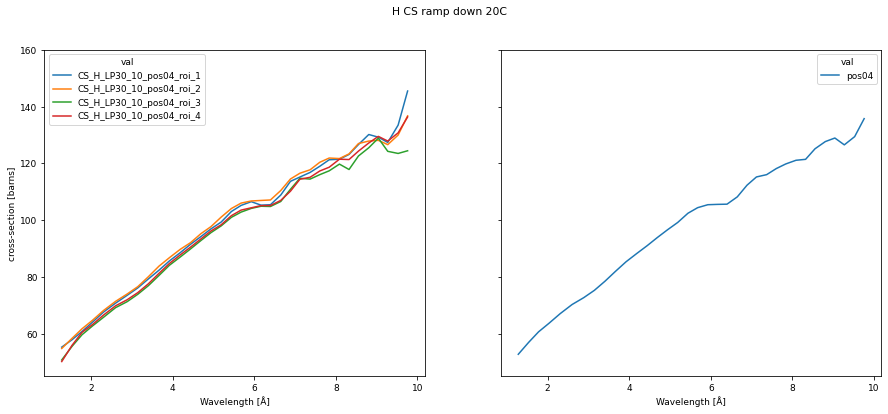

In [151]:
fig0, ax = plt.subplots(1,2, figsize = (15,6), sharey = True)
fig0.suptitle('H CS ramp down 20C')
plt.ylim([45,160])
sns.lineplot(ax = ax[0], data = cs_pos04_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[1], data = avg_vals_dat20, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')

In [152]:
avg_vals_dat_all = pd.DataFrame(data_wvl) 
avg_vals_dat_all ['20C'] = avg_vals_dat20.pivot( columns = 'val', values = 'cross-section [barns]')
avg_vals_dat_all ['10C'] = avg_vals_dat10.pivot( columns = 'val', values = 'cross-section [barns]')
avg_vals_dat_all ['0C'] = avg_vals_dat00.pivot( columns = 'val', values = 'cross-section [barns]')
avg_vals_dat_all ['-10C'] = avg_vals_datm10.pivot( columns = 'val', values = 'cross-section [barns]')
avg_vals_dat_all ['-20C'] = avg_vals_datm20.pivot( columns = 'val', values = 'cross-section [barns]')

,Wavelength [Å],20C,10C,0C,-10C,-20C
0,1.279359,52.700453,54.651404,52.926000,55.077484,54.621598
1,1.531952,56.877970,59.372008,58.193074,59.369498,58.940649
2,1.776463,60.612839,63.575600,62.338130,63.118942,62.711521
3,2.032233,63.633892,67.642746,65.323689,66.472043,66.121315
4,2.304880,67.010093,70.270223,67.166165,68.763447,68.062945
...,...,...,...,...,...,...
30,8.806118,127.695904,121.166269,115.866339,112.386234,107.447387
31,9.039954,128.948974,120.276270,116.065653,112.405324,106.448780
32,9.271439,126.536853,122.923673,115.511748,114.619296,105.310240
33,9.525303,129.438746,125.970905,118.480995,116.698327,109.667434


In [154]:
avg_vals_dat_all=avg_vals_dat_all.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')

[Text(0.5, 1.0, 'Ramp down all averaged')]

C:\Users\carreon_r\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 8491 (\N{ANGSTROM SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


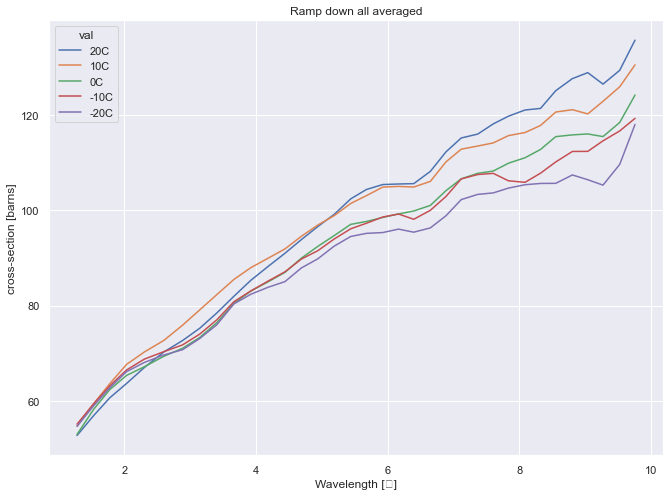

In [168]:
from matplotlib import rcParams
rcParams['figure.figsize'] = 11,8
sns.lineplot( data = avg_vals_dat_all, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val').set(title='Ramp down all averaged')